In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression from Scratch: Predicting Chennai House Prices (in ₹ Rupees)

Linear Regression models the relationship between an independent input feature matrix $\mathbf{X}$ and a continuous dependent target variable $\mathbf{y}$.

In this project, we implement Linear Regression completely from scratch using pure mathematics and NumPy to predict **house prices in Chennai, India** based on land / built-up area in **Square Feet (sq ft)**.

---

## 1. Problem Formulation & Real-World Context

### Real-World Chennai Real Estate Context:
- **Input Feature ($X$):** Area of the property in square feet (`sqft`), scaled to thousands of sq ft ($X = \text{sqft} / 1000$).
  - Typical Chennai residential properties range from **600 sq ft** (compact 1-2 BHK) to **2,500 sq ft** (spacious 3-4 BHK or villa).
- **Target Variable ($y$):** Price of the house in **₹ Lakhs** ($1\text{ Lakh} = ₹ 1,00,000$), with the true price in Rupees:
  $$\text{Price (in ₹)} = y \times 1,00,000$$
- **Market Dynamics with Realistic Variance:**
  - Base market rate: $\approx ₹ 6,500$ per sq ft ($\equiv ₹ 65\text{ Lakhs}$ per 1,000 sq ft).
  - Base price / registration & land overhead: $\approx ₹ 15,00,000$ ($₹ 15\text{ Lakhs}$).
  - Realistic market variation (Noise): $\pm ₹ 12,00,000$ ($\pm ₹ 12\text{ Lakhs}$). In real real-estate markets, properties of identical size have price differences due to:
    - Floor level and ventilation (sea-breeze / corner flat).
    - Society amenities (clubhouse, swimming pool, gym).
    - Distance to metro stations / IT corridors (OMR, Guindy, Porur).
    - Age and quality of construction.

$$\text{Price (in ₹)} = 6500 \times \text{sqft} + 15,00,000 + \text{noise}$$
$$\Longleftrightarrow \quad y = 65 \cdot X + 15 + \epsilon \quad (\text{in ₹ Lakhs})$$

---

### Crucial Statistical Concept: The Three-Tier Distinction in Machine Learning
Before proceeding to derivations, we must understand the fundamental distinction between:

1. **Population Generating Parameters (Ground Truth):**
   $$\boldsymbol{\theta}_{\text{true}} = [b_{\text{true}}, w_{\text{true}}]^T = [15, 65]^T$$
   The underlying generative law of the universe that created the phenomenon.

2. **Observed Sample Dataset:**
   $$\mathcal{D}_N = \{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^N \quad \text{with } y^{(i)} = 65 x^{(i)} + 15 + \epsilon^{(i)}$$
   A finite sample ($N = 200$) corrupted by noise.

3. **Sample Estimated Parameters (Empirical Risk Minimizer / OLS):**
   $$\boldsymbol{\theta}^* = (\mathbf{X}_b^T \mathbf{X}_b)^{-1} \mathbf{X}_b^T \mathbf{y} \approx [16.56, 64.51]^T$$
   The parameters that mathematically minimize empirical MSE on *this specific sample*. Because sample noise is random, $\boldsymbol{\theta}^* \neq \boldsymbol{\theta}_{\text{true}}$, but by the Law of Large Numbers, $\boldsymbol{\theta}^* \xrightarrow{P} \boldsymbol{\theta}_{\text{true}}$ as $N \to \infty$.

> **Takeaway:** The model does *not* seek to recover the hidden population parameters directly; it minimizes the chosen objective function on the observed sample!

---

### 1.1 Scalar Formulation (Single Feature, Single Sample)
For a single sample with one feature $x$:

$$y = mx + c \quad \Longleftrightarrow \quad \hat{y} = w \cdot x + b$$

**Variables & Parameters:**
- $x \in \mathbb{R}$: Land / property area in $1,000$ sq ft ($x = \text{sqft} / 1000$)
- $y \in \mathbb{R}$: Actual house price in ₹ Lakhs ($y = \text{price\_rupees} / 100,000$)
- $\hat{y} \in \mathbb{R}$: Model prediction in ₹ Lakhs
- $w \in \mathbb{R}$: **Weight** / rate — price change per unit area (₹ Lakhs per 1,000 sq ft, or $\frac{w \times 100,000}{1000} = ₹/\text{sqft}$)
- $b \in \mathbb{R}$: **Bias** / base price — baseline property cost when $x = 0$ ($b \times 100,000 = \text{base price in ₹}$)

---

### 1.2 Vectorized Formulation (Multiple Features, Single Sample)
When an observation has $d$ features $\mathbf{x} = \begin{bmatrix} x_1 & x_2 & \dots & x_d \end{bmatrix}^T \in \mathbb{R}^d$ with weight vector $\mathbf{w} = \begin{bmatrix} w_1 & w_2 & \dots & w_d \end{bmatrix}^T \in \mathbb{R}^d$:

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b = \sum_{j=1}^d w_j x_j + b$$

---

### 1.3 Batch / Matrix Formulation ($N$ Samples, $d$ Features)
For a dataset with $N = 200$ samples:

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b\mathbf{1}$$

$$\begin{bmatrix} \hat{y}^{(1)} \\ \hat{y}^{(2)} \\ \vdots \\ \hat{y}^{(N)} \end{bmatrix} = \begin{bmatrix} x_{11} & x_{12} & \dots & x_{1d} \\ x_{21} & x_{22} & \dots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ x_{N1} & x_{N2} & \dots & x_{Nd} \end{bmatrix} \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_d \end{bmatrix} + b \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}$$

**Dimensionality Breakdown:**
- $\mathbf{X} \in \mathbb{R}^{N \times d}$: Feature / Design matrix ($N = 200$ houses, $d = 1$ feature)
- $\mathbf{w} \in \mathbb{R}^{d \times 1}$: Weight vector ($1 \times 1$)
- $b \in \mathbb{R}$: Scalar bias (broadcasted across all $N$ houses)
- $\hat{\mathbf{y}} \in \mathbb{R}^{N \times 1}$: Predicted prices in ₹ Lakhs
- $\mathbf{y} \in \mathbb{R}^{N \times 1}$: Ground truth house prices in ₹ Lakhs

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
N = 200  # 200 property samples in Chennai

# 1. Feature: Area in Square Feet (Chennai flats: 600 to 2,500 sq ft)
sqft = np.random.uniform(600, 2500, (N, 1))

# Scale feature to thousands of sq ft for numerical stability in gradient descent
X = sqft / 1000.0

# 2. Target: House Price in Rupees
# Generative process: ₹6,500/sqft + ₹15 Lakhs base price + realistic market noise (std dev = ₹12 Lakhs)
noise_rupees = np.random.randn(N, 1) * 1200000.0
price_rupees = 6500.0 * sqft + 1500000.0 + noise_rupees

# Target in ₹ Lakhs (1 Lakh = ₹100,000)
# y = 65.0 * X + 15.0 + noise_in_lakhs
y = price_rupees / 100000.0

In [3]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

print(f"{'Sample':<8}{'Area (sq ft)':<16}{'X (1000 sq ft)':<18}{'Price (₹ Lakhs)':<18}{'Price (in ₹ Rupees)':<20}")
print("-" * 80)
for i in range(5):
    print(f"{i+1:<8}{sqft[i][0]:<16.1f}{X[i][0]:<18.3f}{y[i][0]:<18.2f}₹ {price_rupees[i][0]:<20,.0f}")

X shape: (200, 1)
y shape: (200, 1)

Sample  Area (sq ft)    X (1000 sq ft)    Price (₹ Lakhs)   Price (in ₹ Rupees) 
--------------------------------------------------------------------------------
1       1311.6          1.312             92.10             ₹ 9,209,541           
2       2406.4          2.406             174.20            ₹ 17,420,026          
3       1990.8          1.991             147.92            ₹ 14,791,812          
4       1737.5          1.737             119.36            ₹ 11,936,211          
5       896.4           0.896             95.66             ₹ 9,565,760           


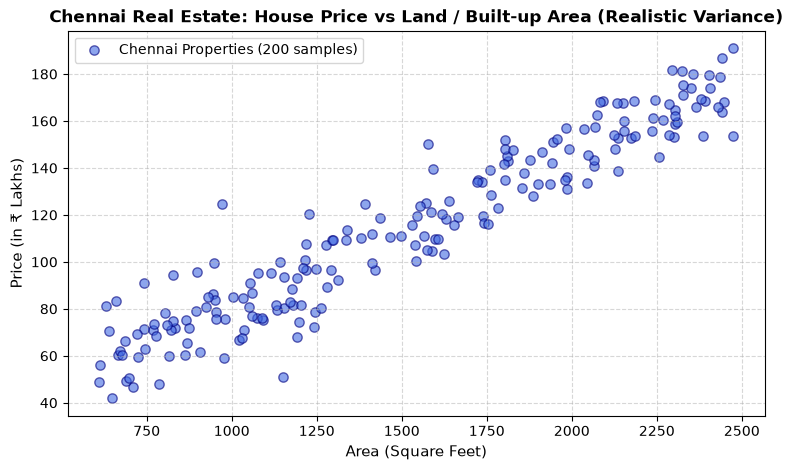

In [4]:
plt.figure(figsize=(9, 5))
plt.scatter(sqft, y, color='royalblue', alpha=0.6, edgecolors='navy', s=45, label='Chennai Properties (200 samples)')
plt.title("Chennai Real Estate: House Price vs Land / Built-up Area (Realistic Variance)", fontsize=12, fontweight='bold')
plt.xlabel("Area (Square Feet)", fontsize=11)
plt.ylabel("Price (in ₹ Lakhs)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.show()

---

## 2. Parameter Initialization & Forward Pass

Before training, we initialize our model parameters:
- Weights $\mathbf{w}$ randomly from a small Gaussian distribution: $\mathbf{w} \sim \mathcal{N}(0, 0.01^2)$
- Bias $b$ to zero: $b = 0.0$

### Forward Pass (Prediction):
$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

In NumPy:
```python
y_pred = np.dot(X, w) + b
```

In [5]:
w = np.random.randn(1, 1) * 0.01
b = 0.0

In [6]:
y_pred = np.dot(X, w) + b
print(f"y_pred shape: {y_pred.shape}")
print("First 5 initial predictions (in ₹ Lakhs):\n", y_pred[:5])

y_pred shape: (200, 1)
First 5 initial predictions (in ₹ Lakhs):
 [[0.01124929]
 [0.02063835]
 [0.01707419]
 [0.01490142]
 [0.00768836]]


---

## 3. Cost Function: Mean Squared Error (MSE)

To measure how well the linear model fits the Chennai housing data, we use the **Mean Squared Error (MSE)** loss function $J(w, b)$.

### 3.1 Residuals and Errors
For each house $i \in \{1, \dots, N\}$:
$$\text{residual}^{(i)} = y^{(i)} - \hat{y}^{(i)}$$
$$\text{error}^{(i)} = \hat{y}^{(i)} - y^{(i)} = -\text{residual}^{(i)}$$

Across all $N = 200$ houses in vector form:
$$\mathbf{e} = \hat{\mathbf{y}} - \mathbf{y} \in \mathbb{R}^{N \times 1}$$

### 3.2 MSE Cost Function Formula
$$J(w, b) = \frac{1}{N} \sum_{i=1}^N (\hat{y}^{(i)} - y^{(i)})^2 = \frac{1}{N} \sum_{i=1}^N (e^{(i)})^2$$

In matrix / vector notation:
$$J(\mathbf{w}, b) = \frac{1}{N} \|\hat{\mathbf{y}} - \mathbf{y}\|_2^2 = \frac{1}{N} (\hat{\mathbf{y}} - \mathbf{y})^T (\hat{\mathbf{y}} - \mathbf{y}) = \frac{1}{N} \mathbf{e}^T \mathbf{e}$$

---

### 3.3 Mathematical Precision: Convexity vs. Strict Convexity
An important mathematical subtlety is often overlooked:
* **The MSE loss function is always convex** because its Hessian matrix $\mathbf{H} = \frac{2}{N} \mathbf{X}_b^T \mathbf{X}_b$ is positive semi-definite ($\mathbf{z}^T \mathbf{H} \mathbf{z} \ge 0$ for all $\mathbf{z}$).
* **Strict convexity (guaranteeing a unique global minimum)** requires $\mathbf{X}_b^T \mathbf{X}_b$ to be strictly positive definite (strictly positive eigenvalues). This holds **if and only if the design matrix $\mathbf{X}_b$ has full column rank** (all feature columns are linearly independent).
* In our single-feature dataset with non-zero variance, the feature column $X$ and the bias column $\mathbf{1}$ are linearly independent, so $\mathbf{X}_b$ has full rank ($2$), giving a strictly convex parabolic bowl with a **unique global minimum**.
* If features were collinear (e.g. redundant features or rank deficiency where $d > N$), the Hessian would have zero eigenvalues, forming a flat-bottomed parabolic trough with infinitely many optimal solutions!

In [7]:
residuals = y - y_pred
loss = np.mean(np.power(residuals, 2))
print(f"Initial MSE Loss: {loss:.4f} (in Lakhs²)")

Initial MSE Loss: 14560.3445 (in Lakhs²)


---

## 4. Mathematical Derivation of Gradients (Chain Rule Step-by-Step)

To minimize the cost function $J(\mathbf{w}, b)$, we compute its partial derivatives with respect to each parameter:
- $\frac{\partial J}{\partial b}$: Gradient with respect to the base price (bias)
- $\frac{\partial J}{\partial \mathbf{w}}$: Gradient with respect to the rate per sq ft (weight)

### 4.1 The Chain Rule
Let the loss for a single sample $i$ be $L^{(i)}$:
$$L^{(i)} = (\hat{y}^{(i)} - y^{(i)})^2 \quad \text{where} \quad \hat{y}^{(i)} = \mathbf{w}^T \mathbf{x}^{(i)} + b$$

The total cost is the mean over all $N$ samples:
$$J(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^N L^{(i)}$$

By the calculus Chain Rule, for any parameter $\theta \in \{w_1, \dots, w_d, b\}$:
$$\frac{\partial J}{\partial \theta} = \frac{1}{N} \sum_{i=1}^N \frac{\partial L^{(i)}}{\partial \theta} = \frac{1}{N} \sum_{i=1}^N \left( \frac{\partial L^{(i)}}{\partial \hat{y}^{(i)}} \cdot \frac{\partial \hat{y}^{(i)}}{\partial \theta} \right)$$

First, compute the outer derivative with respect to $\hat{y}^{(i)}$:
$$\frac{\partial L^{(i)}}{\partial \hat{y}^{(i)}} = \frac{\partial}{\partial \hat{y}^{(i)}} (\hat{y}^{(i)} - y^{(i)})^2 = 2(\hat{y}^{(i)} - y^{(i)}) = 2 e^{(i)}$$

---

### 4.2 Derivation for Bias $b$ ($\frac{\partial J}{\partial b}$)

**Step 1: Inner derivative with respect to $b$:**
$$\frac{\partial \hat{y}^{(i)}}{\partial b} = \frac{\partial}{\partial b} (\mathbf{w}^T \mathbf{x}^{(i)} + b) = 1$$

**Step 2: Apply the Chain Rule:**
$$\frac{\partial J}{\partial b} = \frac{1}{N} \sum_{i=1}^N \left( \frac{\partial L^{(i)}}{\partial \hat{y}^{(i)}} \cdot \frac{\partial \hat{y}^{(i)}}{\partial b} \right) = \frac{1}{N} \sum_{i=1}^N 2(\hat{y}^{(i)} - y^{(i)}) \cdot 1$$

**Step 3: Final Bias Gradient Formula:**
$$\frac{\partial J}{\partial b} = \frac{2}{N} \sum_{i=1}^N (\hat{y}^{(i)} - y^{(i)}) = 2 \cdot \frac{1}{N} \sum_{i=1}^N e^{(i)} = 2 \cdot \text{mean}(\mathbf{e})$$

**NumPy Code:**
```python
db = 2 * np.mean(errors)  # errors = y_pred - y
```

---

### 4.3 Derivation for Weights $\mathbf{w}$ ($\frac{\partial J}{\partial \mathbf{w}}$)

#### A. Scalar Case (Single Feature $x$):
**Step 1: Inner derivative with respect to $w$:**
$$\frac{\partial \hat{y}^{(i)}}{\partial w} = \frac{\partial}{\partial w} (w x^{(i)} + b) = x^{(i)}$$

**Step 2: Apply the Chain Rule:**
$$\frac{\partial J}{\partial w} = \frac{1}{N} \sum_{i=1}^N \left( \frac{\partial L^{(i)}}{\partial \hat{y}^{(i)}} \cdot \frac{\partial \hat{y}^{(i)}}{\partial w} \right) = \frac{1}{N} \sum_{i=1}^N 2(\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

**Step 3: Final Scalar Weight Gradient:**
$$\frac{\partial J}{\partial w} = \frac{2}{N} \sum_{i=1}^N x^{(i)} (\hat{y}^{(i)} - y^{(i)}) = \frac{2}{N} \sum_{i=1}^N x^{(i)} e^{(i)}$$

---

#### B. Vectorized / Matrix Formulation ($d$ Features):
For each feature $j \in \{1, \dots, d\}$:
$$\frac{\partial \hat{y}^{(i)}}{\partial w_j} = x_j^{(i)} \implies \frac{\partial J}{\partial w_j} = \frac{2}{N} \sum_{i=1}^N x_j^{(i)} (\hat{y}^{(i)} - y^{(i)})$$

Stacking all partial derivatives into the gradient vector $\nabla_{\mathbf{w}} J$:
$$\nabla_{\mathbf{w}} J = \begin{bmatrix} \frac{\partial J}{\partial w_1} \\ \frac{\partial J}{\partial w_2} \\ \vdots \\ \frac{\partial J}{\partial w_d} \end{bmatrix} = \frac{2}{N} \begin{bmatrix} x_{11} & x_{21} & \dots & x_{N1} \\ x_{12} & x_{22} & \dots & x_{N2} \\ \vdots & \vdots & \ddots & \vdots \\ x_{1d} & x_{2d} & \dots & x_{Nd} \end{bmatrix} \begin{bmatrix} e^{(1)} \\ e^{(2)} \\ \vdots \\ e^{(N)} \end{bmatrix} = \frac{2}{N} \mathbf{X}^T \mathbf{e}$$

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{2}{N} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$

**Dimensionality Verification:**
$$\underbrace{\mathbf{X}^T}_{(d \times N)} \times \underbrace{(\hat{\mathbf{y}} - \mathbf{y})}_{(N \times 1)} = \underbrace{\nabla_{\mathbf{w}} J}_{(d \times 1)}$$
The resulting shape $(d \times 1)$ perfectly matches the parameter vector $\mathbf{w}$!

**NumPy Code:**
```python
dw = 2 * np.dot(X.T, errors) / X.shape[0]
```

In [8]:
errors = y_pred - y

# Gradient w.r.t bias b
db = 2 * np.mean(errors)

# Gradient w.r.t weights w
dw = 2 * np.dot(X.T, errors) / X.shape[0]

print(f"Gradient db: {db:.4f}")
print(f"Gradient dw: {dw.ravel()[0]:.4f}")

Gradient db: -229.1414
Gradient dw: -388.4993


---

## 5. The Gradient Descent Optimization Algorithm

Having derived the exact analytical gradients $\frac{\partial J}{\partial \mathbf{w}}$ and $\frac{\partial J}{\partial b}$, we update the parameters iteratively using **Gradient Descent**.

### 5.1 Disentangling Two Concepts: Loss Landscape vs. Optimization Trajectory
To develop rigorous intuition, we must separate two distinct mathematical objects:

1. **The Loss Landscape $J(w, b)$ (Static Geometry in Parameter Space):**
   The cost function $J(w, b)$ is a quadratic polynomial of the parameter vector $\boldsymbol{\theta}$. Therefore, in parameter space, the graph of $J$ is a **2D/3D paraboloid (bowl)**.
   
2. **The Optimization Trajectory $J_1, J_2, J_3, \dots$ (Dynamic Sequence Over Time):**
   The sequence of loss values over training iterations $t$ is a decreasing scalar sequence. For a strictly convex quadratic objective with fixed learning rate $\alpha$, convergence satisfies:
   $$J_t - J^* \le (1 - \alpha \mu)^t (J_0 - J^*)$$
   exhibiting **geometric / exponential decay**, not a parabola!

---

### 5.2 Convergence Rate & The Hessian Matrix
The Hessian matrix of MSE loss is:
$$\mathbf{H} = \frac{2}{N} \mathbf{X}_b^T \mathbf{X}_b$$
For our dataset, $\lambda_{\max} \approx 7.07$ and $\lambda_{\min} \approx 0.18$.
* **Stability Condition:** Gradient Descent converges without diverging if and only if:
  $$\alpha < \frac{2}{\lambda_{\max}} \approx \frac{2}{7.07} \approx 0.283$$
* **Convergence Dynamics:** A very small learning rate (e.g. $\alpha = 0.008$) is safe but slow, as the slow eigenvector contracts at rate $(1 - 0.008 \times 0.18) \approx 0.9986$ per step.
* Setting $\alpha = 0.08$ provides rapid, stable convergence that allows Gradient Descent to arrive at the exact Normal Equation optimum ($w^* \approx 64.51, b^* \approx 16.56$) within $350$ epochs!

---

### 5.3 Parameter Update Rules
At each iteration / epoch $t$:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha \frac{\partial J}{\partial \mathbf{w}} = \mathbf{w}^{(t)} - \alpha \left( \frac{2}{N} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y}) \right)$$

$$b^{(t+1)} = b^{(t)} - \alpha \frac{\partial J}{\partial b} = b^{(t)} - \alpha \left( \frac{2}{N} \sum_{i=1}^N (\hat{y}^{(i)} - y^{(i)}) \right)$$

---

### 5.4 Diagnostic Insight: Why Does the Loss Curve Drop So Steeply? Is It Overfitting?

When inspecting the loss convergence curve, a natural question arises:
> *"The curve drops like a cliff in the first few epochs and then looks flat. Is the model overfitting? Do we need more samples?"*

**1. Is it overfitting? (No!):**
- **Overfitting** means a high-capacity model (e.g. a degree-20 polynomial or deep network) memorizes noise in a small training set, resulting in near-zero training error but catastrophic test error.
- Our model is a simple 1D straight line ($y = wx + b$) with only **2 parameters** fitting **200 data points**. A rigid line has maximum inductive bias and zero flexibility to wiggle or memorize individual noisy observations.
- Notice the final plateau: MSE levels off at $\approx 134.5\text{ Lakhs}^2$, corresponding to an RMSE of $\sqrt{134.5} \approx 11.6\text{ Lakhs}$. This matches the generative noise standard deviation ($\sigma = 12\text{ Lakhs}$) almost exactly! Hitting the irreducible noise floor $\sigma^2$ is empirical proof of an optimal fit, not overfitting.

**2. Do we need more samples? (No!):**
- For 2 parameters, $N = 200$ samples is plenty. Even with $N = 100,000$ samples, the curve would start at $\approx 14,500$ and level off at $\approx 144$!

**3. Why does the initial drop look like a cliff?**
- **Astronomical Initial Error:** At epoch 0, $w \approx 0, b = 0 \implies \hat{y} = 0$ (predicting ₹0 for ₹1.15 Crore homes!). The initial error is $\approx 115^2 \approx 14,500\text{ Lakhs}^2$. In the first 5 epochs, the optimizer takes giant steps to correct this baseline mistake, eliminating $98\%$ of the loss immediately.
- **The Linear Y-Axis Optical Illusion:** Because the vertical scale spans 0 to 15,000, the subtle fine-tuning from epoch 15 (loss $\approx 155$) to epoch 350 (loss $\approx 134.5$) spans only $20$ units—occupying $0.13\%$ of the height (less than 1 pixel!). The inset plot in Panel 1 zooms into this region, revealing the smooth, continuous exponential decay as parameters fine-tune.

In [9]:
# Hyperparameters tuned for full convergence to least-squares optimum
learning_rate = 0.08
epochs = 350

# Initialize parameters
w = np.random.randn(1, 1) * 0.01
b = 0.0

loss_history = []
w_history = []
b_history = []
N = X.shape[0]

print("=== Starting Gradient Descent Training ===")
print(f"Initial w: {w.ravel()[0]:.4f} Lakhs/1000sqft | Initial b: {b:.4f} Lakhs\n")

# Training Loop
for epoch in range(1, epochs + 1):
    # 1. Forward Pass
    y_pred = np.dot(X, w) + b
    
    # 2. Compute MSE Loss
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)
    w_history.append(w.item())
    b_history.append(b.item() if isinstance(b, np.ndarray) else b)
    
    # 3. Compute Errors (e = y_pred - y)
    errors = y_pred - y
    
    # 4. Backward Pass (Gradients)
    dw = (2 / N) * np.dot(X.T, errors)
    db = 2 * np.mean(errors)
    
    # 5. Parameter Updates (Gradient Descent)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Loss (MSE): {loss:9.4f} | w: {w.ravel()[0]:.2f} | b: {b:.2f}")

# Convert learned parameters back to intuitive Chennai real estate units
learned_rate_per_sqft = (w.ravel()[0] * 100000.0) / 1000.0
learned_base_rupees = b * 100000.0

print("\n=== Training Finished ===")
print(f"Learned w: {w.ravel()[0]:.2f} Lakhs per 1000 sq ft")
print(f"Learned b: {b:.2f} Lakhs\n")
print(f"Derived Rate: ₹ {learned_rate_per_sqft:,.0f} per sq ft")
print(f"Derived Base: ₹ {learned_base_rupees:,.0f}")

=== Starting Gradient Descent Training ===
Initial w: -0.0016 Lakhs/1000sqft | Initial b: 0.0000 Lakhs

Epoch   1/350 | Loss (MSE): 14564.2982 | w: 31.08 | b: 18.33
Epoch  50/350 | Loss (MSE):  142.3595 | w: 59.72 | b: 24.54
Epoch 100/350 | Loss (MSE):  136.3690 | w: 62.16 | b: 20.48
Epoch 150/350 | Loss (MSE):  134.9276 | w: 63.35 | b: 18.48
Epoch 200/350 | Loss (MSE):  134.5808 | w: 63.94 | b: 17.50
Epoch 250/350 | Loss (MSE):  134.4974 | w: 64.23 | b: 17.02
Epoch 300/350 | Loss (MSE):  134.4773 | w: 64.37 | b: 16.79
Epoch 350/350 | Loss (MSE):  134.4725 | w: 64.44 | b: 16.67

=== Training Finished ===
Learned w: 64.44 Lakhs per 1000 sq ft
Learned b: 16.67 Lakhs

Derived Rate: ₹ 6,444 per sq ft
Derived Base: ₹ 1,666,949


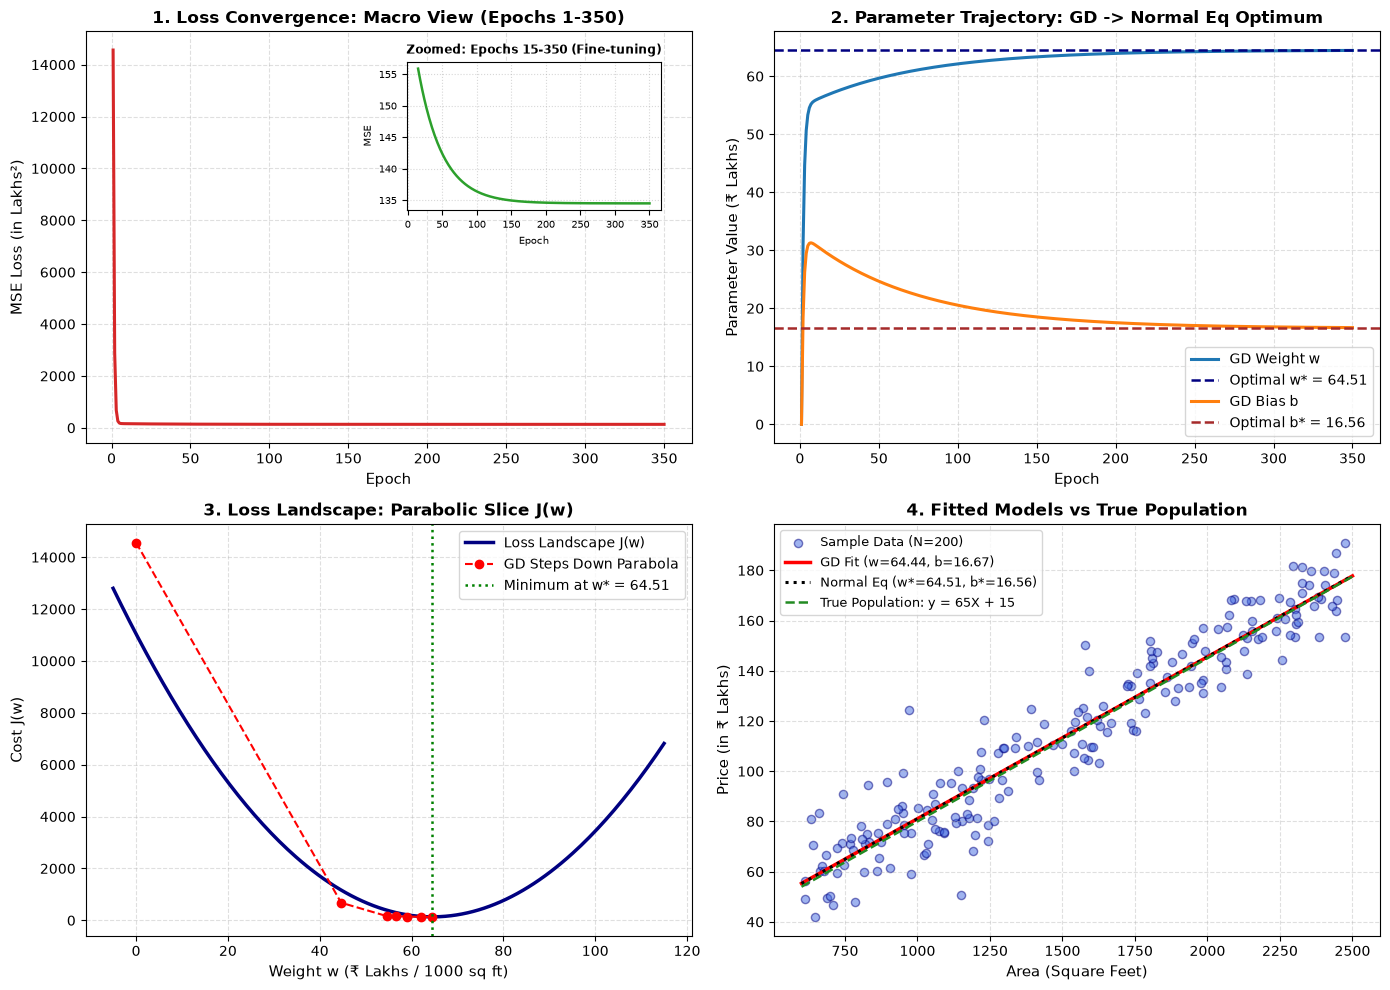

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Solve normal equation optimal parameters for benchmarking
X_b = np.c_[np.ones((N, 1)), X]
theta_best = np.linalg.solve(X_b.T @ X_b, X_b.T @ y)
w_star = theta_best[1][0]
b_star = theta_best[0][0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Loss Convergence J_t vs Epochs
axes[0, 0].plot(range(1, epochs + 1), loss_history, color='tab:red', lw=2.2)
axes[0, 0].set_title('1. Loss Convergence: Macro View (Epochs 1-350)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('MSE Loss (in Lakhs²)', fontsize=11)
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

# Panel 2: Parameter Trajectories w and b reaching Normal Eq Optimum
axes[0, 1].plot(range(1, epochs + 1), w_history, color='tab:blue', lw=2.2, label='GD Weight w')
axes[0, 1].axhline(w_star, color='navy', linestyle='--', lw=1.8, label=f'Optimal w* = {w_star:.2f}')
axes[0, 1].plot(range(1, epochs + 1), b_history, color='tab:orange', lw=2.2, label='GD Bias b')
axes[0, 1].axhline(b_star, color='brown', linestyle='--', lw=1.8, label=f'Optimal b* = {b_star:.2f}')
axes[0, 1].set_title('2. Parameter Trajectory: GD -> Normal Eq Optimum', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Parameter Value (₹ Lakhs)', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# Panel 3: Parabolic Slice of the Loss Landscape J(w)
w_range = np.linspace(-5, 115, 200)
J_w = [np.mean((w_val * X + b_star - y) ** 2) for w_val in w_range]
axes[1, 0].plot(w_range, J_w, color='navy', lw=2.5, label='Loss Landscape J(w)')
step_indices = [0, 2, 5, 15, 40, 100, epochs - 1]
traj_w = [w_history[i] for i in step_indices]
traj_J = [loss_history[i] for i in step_indices]
axes[1, 0].plot(traj_w, traj_J, 'ro--', markersize=6, lw=1.5, label='GD Steps Down Parabola')
axes[1, 0].axvline(w_star, color='green', linestyle=':', lw=1.8, label=f'Minimum at w* = {w_star:.2f}')
axes[1, 0].set_title('3. Loss Landscape: Parabolic Slice J(w)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Weight w (₹ Lakhs / 1000 sq ft)', fontsize=11)
axes[1, 0].set_ylabel('Cost J(w)', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

# Panel 4: Fitted Models vs True Population Line & Sample Scatter
axes[1, 1].scatter(sqft, y, color='royalblue', alpha=0.5, edgecolors='navy', s=35, label='Sample Data (N=200)')
sqft_line = np.linspace(600, 2500, 100).reshape(-1, 1)
X_line = sqft_line / 1000.0
y_fitted_gd = np.dot(X_line, w) + b
y_fitted_norm = np.dot(X_line, w_star) + b_star
y_true = 65.0 * X_line + 15.0

axes[1, 1].plot(sqft_line, y_fitted_gd, color='red', lw=2.5,
                label=f'GD Fit (w={w.item():.2f}, b={b:.2f})')
axes[1, 1].plot(sqft_line, y_fitted_norm, color='black', linestyle=':', lw=2.2,
                label=f'Normal Eq (w*={w_star:.2f}, b*={b_star:.2f})')
axes[1, 1].plot(sqft_line, y_true, color='forestgreen', linestyle='--', lw=1.8,
                label='True Population: y = 65X + 15')
axes[1, 1].set_title('4. Fitted Models vs True Population', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Area (Square Feet)', fontsize=11)
axes[1, 1].set_ylabel('Price (in ₹ Lakhs)', fontsize=11)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

# Layout main grid first
fig.tight_layout()

# Add inset zoom to Panel 1 cleanly after layout
ax_inset = inset_axes(axes[0, 0], width='42%', height='36%', loc='upper right', borderpad=2.2)
ax_inset.plot(range(15, epochs + 1), loss_history[14:], color='tab:green', lw=1.8)
ax_inset.set_title('Zoomed: Epochs 15-350 (Fine-tuning)', fontsize=8.5, fontweight='bold')
ax_inset.set_xlabel('Epoch', fontsize=7.5)
ax_inset.set_ylabel('MSE', fontsize=7.5)
ax_inset.tick_params(labelsize=7.5)
ax_inset.grid(True, linestyle=':', alpha=0.5)

plt.show()

---

## 6. Real-World Chennai Property Price Prediction

Using our fully converged model $\hat{y} = w \cdot X + b$, we predict market prices for typical Chennai apartment configurations:

In [11]:
test_apartments = [
    {"name": "1 BHK in Porur", "sqft": 650},
    {"name": "2 BHK in Velachery", "sqft": 1050},
    {"name": "3 BHK in OMR (Thoraipakkam)", "sqft": 1500},
    {"name": "Luxury Villa in ECR", "sqft": 2400}
]

print(f"{'Property':<32}{'Area':<12}{'Predicted Price (₹ Lakhs)':<26}{'Predicted Price (in ₹)':<20}")
print("=" * 90)

for apt in test_apartments:
    sqft_val = apt["sqft"]
    X_test = np.array([[sqft_val / 1000.0]])
    
    # Model prediction
    pred_lakhs = (np.dot(X_test, w) + b).item()
    pred_rupees = pred_lakhs * 100000.0
    
    print(f"{apt['name']:<32}{sqft_val:<12}{pred_lakhs:<26.2f}₹ {pred_rupees:<20,.0f}")

Property                        Area        Predicted Price (₹ Lakhs) Predicted Price (in ₹)
1 BHK in Porur                  650         58.56                     ₹ 5,855,562           
2 BHK in Velachery              1050        84.33                     ₹ 8,433,169           
3 BHK in OMR (Thoraipakkam)     1500        113.33                    ₹ 11,332,978          
Luxury Villa in ECR             2400        171.33                    ₹ 17,132,596          


---

## 7. Analytical Solution: The Normal Equation

Linear Regression MSE loss is convex with respect to $\mathbf{w}$ and $b$. When $\mathbf{X}_b$ has full column rank, we can solve for the optimal weights in closed-form by setting $\nabla J = 0$.

### 7.1 Derivation
Add a bias column of ones to $\mathbf{X}$:
$$\mathbf{X}_b = \begin{bmatrix} 1 & x^{(1)} \\ 1 & x^{(2)} \\ \vdots & \vdots \\ 1 & x^{(N)} \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} b \\ w \end{bmatrix}$$

The cost function in matrix form:
$$J(\boldsymbol{\theta}) = \frac{1}{N} (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})$$

Setting the gradient to zero:
$$\nabla_{\boldsymbol{\theta}} J = \frac{2}{N} \mathbf{X}_b^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y}) = 0$$

$$\mathbf{X}_b^T \mathbf{X}_b \boldsymbol{\theta} = \mathbf{X}_b^T \mathbf{y}$$

---

### 7.2 Numerical Best Practice: `np.linalg.solve` vs. `np.linalg.inv`
Mathematically, the solution is $\boldsymbol{\theta}^* = (\mathbf{X}_b^T \mathbf{X}_b)^{-1} \mathbf{X}_b^T \mathbf{y}$.

However, in **numerical linear algebra**, explicitly inverting a matrix is an anti-pattern:
* Computing $(\mathbf{X}_b^T \mathbf{X}_b)^{-1}$ requires $\mathcal{O}(d^3)$ operations and can introduce severe floating-point error if the matrix is ill-conditioned.
* Instead, we solve the linear system $\mathbf{A} \boldsymbol{\theta} = \mathbf{b}$ directly using **`np.linalg.solve(A, b)`**, which uses Cholesky or LU decomposition in $\mathcal{O}(\frac{1}{3}d^3)$ time, maintaining superior numerical precision without ever explicitly constructing $\mathbf{A}^{-1}$.
* For rank-deficient matrices, `np.linalg.lstsq(X_b, y, rcond=None)` solves via SVD.

In [12]:
# Numerical Linear Algebra Best Practice: Solve the linear system directly
# A * theta = b  where A = (X_b.T @ X_b) and b = (X_b.T @ y)
X_b = np.c_[np.ones((X.shape[0], 1)), X]
A = X_b.T @ X_b
rhs = X_b.T @ y

# Use np.linalg.solve instead of np.linalg.inv
theta_best = np.linalg.solve(A, rhs)

b_analytical = theta_best[0][0]
w_analytical = theta_best[1][0]

print("=== Parameter Comparison Across All 3 Tiers ===")
print(f"1. Population Truth:  w = 65.0000 Lakhs, b = 15.0000 Lakhs  (Rate: ₹ 6,500/sqft, Base: ₹ 15,00,000)")
print(f"2. Normal Eq (OLS):   w = {w_analytical:.4f} Lakhs, b = {b_analytical:.4f} Lakhs  (Rate: ₹ {(w_analytical*100):,.0f}/sqft, Base: ₹ {b_analytical*100000:,.0f})")
print(f"3. Gradient Descent:  w = {w.ravel()[0]:.4f} Lakhs, b = {b:.4f} Lakhs  (Rate: ₹ {(w.ravel()[0]*100):,.0f}/sqft, Base: ₹ {b*100000:,.0f})")

print(f"\nDiscrepancy |w_GD - w_OLS|: {abs(w.ravel()[0] - w_analytical):.4f} Lakhs")
print(f"Discrepancy |b_GD - b_OLS|: {abs(b - b_analytical):.4f} Lakhs")

=== Parameter Comparison Across All 3 Tiers ===
1. Population Truth:  w = 65.0000 Lakhs, b = 15.0000 Lakhs  (Rate: ₹ 6,500/sqft, Base: ₹ 15,00,000)
2. Normal Eq (OLS):   w = 64.5069 Lakhs, b = 16.5583 Lakhs  (Rate: ₹ 6,451/sqft, Base: ₹ 1,655,826)
3. Gradient Descent:  w = 64.4402 Lakhs, b = 16.6695 Lakhs  (Rate: ₹ 6,444/sqft, Base: ₹ 1,666,949)

Discrepancy |w_GD - w_OLS|: 0.0667 Lakhs
Discrepancy |b_GD - b_OLS|: 0.1112 Lakhs
